# Feature Selection. Data clusterization

In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

## 1. Loading and Handling Data

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/ElenaNKn/data_projects/refs/heads/master/project_clustering_pipelines_feature_selection/project_data.csv")

In [4]:
df.head()

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,fare_amount
0,2011-11-23 14:36:35.0000003,2011-11-23 14:36:35 UTC,-73.959075,40.783316,-73.959087,40.783345,1.0,2.5
1,2013-09-14 21:40:00.00000016,2013-09-14 21:40:00 UTC,-73.931612,40.771060,-73.929097,40.760542,1.0,5.5
2,2012-04-30 18:13:19.0000002,2012-04-30 18:13:19 UTC,-73.997929,40.740983,-74.007197,40.727725,2.0,6.5
3,2010-10-22 15:03:47.0000001,2010-10-22 15:03:47 UTC,-73.980608,40.742449,-73.985609,40.755807,1.0,6.5
4,2011-02-18 18:08:16.0000002,2011-02-18 18:08:16 UTC,-74.008884,40.720314,-73.983280,40.722350,1.0,12.1


In [5]:
df.shape

(615962, 8)

Check for missing values

In [6]:
df.isna().sum()

key                  0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      1
dropoff_longitude    3
dropoff_latitude     3
passenger_count      1
fare_amount          1
dtype: int64

Since the number of entries with missing values is insignificant compared to the size of the dataset, we will remove the entries with missing values

In [7]:
df.dropna(inplace=True)
df.shape

(615959, 8)

Remove the `key` column from the data, since it duplicates information from `pickup_datetime`

In [8]:
df.drop('key', axis=1, inplace=True)
df.head()

,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,fare_amount
0,2011-11-23 14:36:35 UTC,-73.959075,40.783316,-73.959087,40.783345,1.0,2.5
1,2013-09-14 21:40:00 UTC,-73.931612,40.771060,-73.929097,40.760542,1.0,5.5
2,2012-04-30 18:13:19 UTC,-73.997929,40.740983,-74.007197,40.727725,2.0,6.5
3,2010-10-22 15:03:47 UTC,-73.980608,40.742449,-73.985609,40.755807,1.0,6.5
4,2011-02-18 18:08:16 UTC,-74.008884,40.720314,-73.983280,40.722350,1.0,12.1


Process the `pickup_datetime` column. Extract 4 new columns from it:
* `year` – the year of the trip
* `month` – the month of the trip
* `day` – the day of the trip
* `hour` – the hour of the trip (rounding rule for hour: if there are less than 30 minutes left until the next hour, round up to the next hour).

Then remove the `pickup_datetime` column

In [9]:
df['year'] = df['pickup_datetime'].str[:4].astype(int)
df['month'] = df['pickup_datetime'].str[5:7].astype(int)
df['day'] = df['pickup_datetime'].str[8:10].astype(int)
df['minute'] = df['pickup_datetime'].str[14:16].astype(int)
df['hour'] = df['pickup_datetime'].str[11:13].astype(int) + (df['minute'] > 30)
df.drop('minute', axis=1, inplace=True)
df.drop('pickup_datetime', axis=1, inplace=True)
df.head(n=7)

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,fare_amount,year,month,day,hour
0,-73.959075,40.783316,-73.959087,40.783345,1.0,2.5,2011,11,23,15
1,-73.931612,40.771060,-73.929097,40.760542,1.0,5.5,2013,9,14,22
2,-73.997929,40.740983,-74.007197,40.727725,2.0,6.5,2012,4,30,18
3,-73.980608,40.742449,-73.985609,40.755807,1.0,6.5,2010,10,22,15
4,-74.008884,40.720314,-73.983280,40.722350,1.0,12.1,2011,2,18,18
5,-73.973728,40.791937,-73.960058,40.805453,5.0,5.7,2010,3,10,15
6,-73.954463,40.784145,-73.951115,40.774394,2.0,6.7,2009,1,29,17


Output summary statistics and info for the dataset columns

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 615959 entries, 0 to 615960
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   pickup_longitude   615959 non-null  float64
 1   pickup_latitude    615959 non-null  float64
 2   dropoff_longitude  615959 non-null  float64
 3   dropoff_latitude   615959 non-null  float64
 4   passenger_count    615959 non-null  float64
 5   fare_amount        615959 non-null  float64
 6   year               615959 non-null  int64  
 7   month              615959 non-null  int64  
 8   day                615959 non-null  int64  
 9   hour               615959 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 51.7 MB


## 2. EDA

Let's perform an initial data analysis to uncover patterns or other insights.

First, we'll identify the years covered by the dataset

In [11]:
df['year'].value_counts()

year
2012    99060
2011    97898
2013    96329
2009    94465
2010    93419
2014    92051
2015    42737
Name: count, dtype: int64

Identify the hour with the maximum number of trips

In [12]:
df['hour'].value_counts(ascending=False)

hour
19    38614
20    37536
21    35666
22    34962
18    34911
23    32451
15    30996
14    30520
12    30083
13    30003
9     28772
10    27864
11    27821
16    27312
17    26607
8     26038
1     20764
7     17857
2     15608
24    13989
0     13441
3     11345
4      8789
6      8392
5      5618
Name: count, dtype: int64

Visualize these results with a histogram

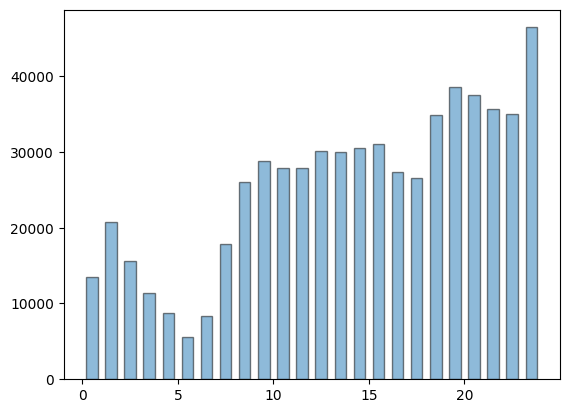

In [13]:
plt.hist(df.hour, bins=24, rwidth=0.6, alpha=0.5, histtype='bar', ec='black');

Now we'll determine which season (winter, spring, summer, autumn) had the fewest number of trips

In [14]:
summer = df[(df.month>=6) & (df.month<= 8)].shape[0]
autumn = df[(df.month>=9) & (df.month<= 11)].shape[0]
winter = df[(df.month==12) | (df.month<= 2)].shape[0]
spring = df[(df.month>=3) & (df.month<= 5)].shape[0]

In [15]:
print(f'summer = {summer} \nautumn = {autumn} \nwinter = {winter} \nspring = {spring}')

summer = 146371 
autumn = 143373 
winter = 153973 
spring = 172242


In [17]:
seasons = {'summer': summer, 'autumn': autumn, 'winter': winter, 'spring': spring}
res = {key:val for key,val in seasons.items() if val == max(seasons.values())}
print(res)

{'spring': 172242}


From the results obtained, we can see that the highest demand is observed in the spring season. Peak hours are in the late afternoon (after work and in the evening).

Let's check the data for outliers by visualizing passenger pick-up locations. To do this, build a scatter plot with `pickup_latitude` and `pickup_longitude` as the axes

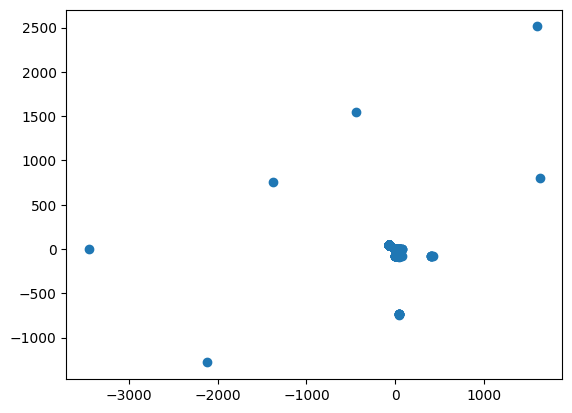

In [18]:
plt.scatter(df['pickup_latitude'], df['pickup_longitude']);

It can be obsearved that there are several outliers where taxis were called to highly remote locations 

Let's plot boxplot for `pickup_longitude`

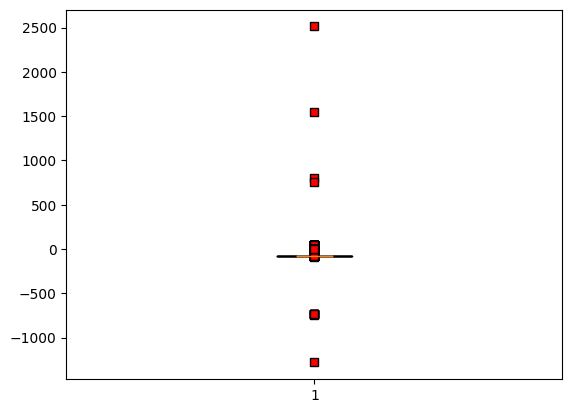

In [19]:
plt.boxplot(df.pickup_longitude,
            notch = True,
            flierprops = dict(marker = "s", markerfacecolor = "red"));

The boxplot also shows that there are outliers in the dataset. But we'll not delete them for now

## 3. Creation of Baseline Model

The 'fare_amount' column will be considered as the target variable. We'll divide the dataset into training and testing subsets

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
y = df.fare_amount
X = df.drop('fare_amount', axis=1, inplace=False)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

We'll train a decision tree with a depth of 3 on the training data and compute the $R^2$ error on the test set

In [23]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [24]:
model_tree_base = DecisionTreeRegressor(max_depth=3, random_state=42)
model_tree_base.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [25]:
pred = model_tree_base.predict(X_test)
r2_value = r2_score(y_test, pred)
print(round(r2_value, 2))

0.5


Now we can plot a barchat of the features' importance

In [26]:
import seaborn as sns

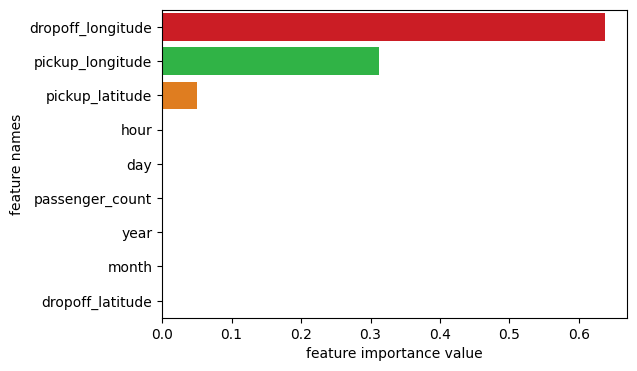

In [27]:
sorted_ind = model_tree_base.feature_importances_.argsort()[::-1]
sorted_feature_names = X.columns[sorted_ind]
sorted_importances = model_tree_base.feature_importances_[sorted_ind]
data = pd.DataFrame(sorted_importances, index=sorted_feature_names, columns=['importance'])

fig = plt.figure(figsize=(6, 4))
plt.xlabel("feature importance value")
plt.ylabel("feature names")

sns.barplot(x=data.importance, y=data.index, data=data, hue=data.importance, legend=False, palette='bright')
plt.show()

We can see that the passenger's pick-up and drop-off longitudes have the greatest weight in predicting the trip fare

## 4. Refinement of the Model

### 4.1. Log Transformation of the Target Variable

Let's build a histogram showing the distribution of the target variable `y`

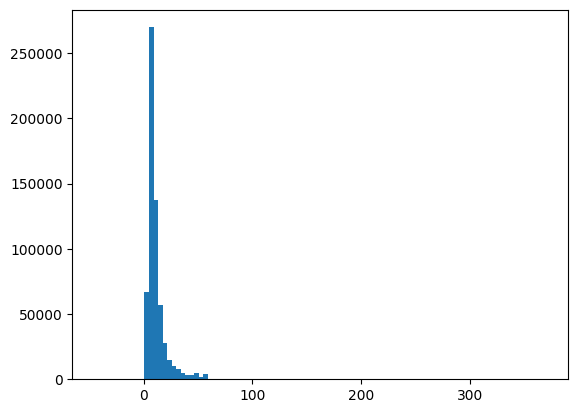

In [28]:
plt.hist(y, bins=100);

Next we'll set all negative values of $y$ to 0, then transform the target variable as $y_{new} = np.log1p(y)$.

Now we can examine the change in the target variable's distribution

In [29]:
y = np.where(y < 0, 0, y)

y_new = np.log1p(y)

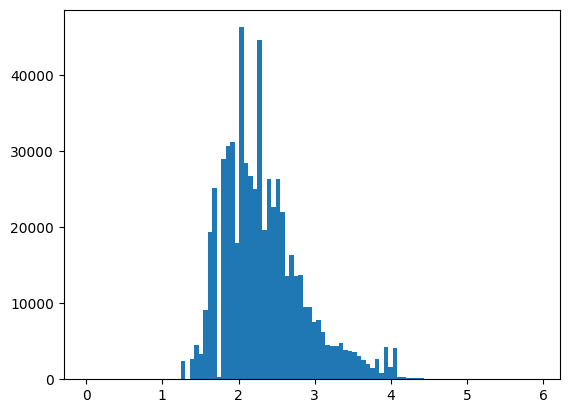

In [30]:
plt.hist(y_new, bins=100);

The distribution has become somewhat closer to normal. Split the data into training and test sets again (based on `X` and `y_new`).

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y_new, test_size=0.25, random_state=42)

Let's retrain the decision tree with depth 3 and `random_state=42` on the training data, and compute $R^2$ on the test set (taking into account the need to reverse-transform the predictions using `np.expm1(pred)` and also applying the same to `y_test`)

In [32]:
model_tree_log = DecisionTreeRegressor(max_depth=3, random_state=42)
model_tree_log.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [33]:
pred = model_tree_log.predict(X_test)
r2_value = r2_score(np.expm1(y_test), np.expm1(pred))
print(round(r2_value, 2))

0.44


Next we'll perform cross-validation on the training data to tune the tree depth over the range of 3 to 10 (inclusive, `step=1`).

Then apply the model with the best-found depth to the test data and calculate $R^2$.

In [34]:
from sklearn.model_selection import GridSearchCV

params = {'max_depth' : np.arange(3, 11, 1)} 

gs = GridSearchCV(DecisionTreeRegressor(random_state=42), params, cv=3, scoring='r2')

gs.fit(X_train, y_train)

print(gs.best_score_)
print(gs.best_params_)

0.5620561878845917
{'max_depth': np.int64(10)}


In [35]:
model_tree_log_tuned = gs.best_estimator_

In [36]:
pred = model_tree_log_tuned.predict(X_test)
r2_value = r2_score(np.expm1(y_test), np.expm1(pred))
print(round(r2_value, 2))

0.68


We can see that applying a logarithmic transformation to the target variable (switching to a log-normal distribution) has improved the model's performance

### 4.2. Adding polynomial features. Defining the pipeline

We'll construct a pipeline where polynomial features (degree 2) are added first, and then a decision tree (max_depth=3) is trained

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

p1 = Pipeline([
    ('features', PolynomialFeatures(degree=2)),
    ('model', DecisionTreeRegressor(max_depth=3, random_state=42))
])

In [38]:
p1.fit(X_train, y_train)

,steps,"[('features', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,criterion,'squared_error'
,splitter,'best'
,max_depth,3


In [39]:
pred = p1.predict(X_test)
r2_value = r2_score(np.expm1(y_test), np.expm1(pred))
print(round(r2_value, 2))

0.42


New we'll again perform cross-validation to tune the tree depth inside the pipeline across the range of 3 to 10 (inclusive, step 1)

In [40]:
params = {'model__max_depth' : np.arange(3, 11, 1)} 

gs2 = GridSearchCV(p1, params, cv=3, scoring='r2')

gs2.fit(X_train, y_train)

print(gs2.best_score_)
print(gs2.best_params_)

0.6658646975340577
{'model__max_depth': np.int64(10)}


Then we can apply the model with the best-found depth to the test data and calculate $R^2$.

In [41]:
model_pipeline_tuned = gs2.best_estimator_

pred = model_pipeline_tuned.predict(X_test)
r2_value = r2_score(np.expm1(y_test), np.expm1(pred))
print(round(r2_value, 2))

0.71


From the obtained result, we can see that adding polynomial features has significantly improved the performance of the decision tree model

### 4.3. Feature selection

Let's try to improve the previous pipeline with the next transformations:
* normalization using `StandardScaler` (in theory, normalization should not affect the quality of tree-based models, but let's see how it works in practice);
* dimensionality reduction using `SelectFromModel` with a `Ridge` model using default hyperparameters

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso, Ridge

p2 = Pipeline([
    ('features', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(Ridge())),
    ('model', DecisionTreeRegressor(max_depth=3, random_state=42))
])

Let's train the pipeline using the training dataset, predict on the test data, and evaluate the $R^2$ score

In [44]:
p2.fit(X_train, y_train)

,steps,"[('features', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [45]:
pred = p2.predict(X_test)
r2_value = r2_score(np.expm1(y_test), np.expm1(pred))
print(round(r2_value, 2))

0.44


By analogy with the previous models, we will tune the depth of the decision tree in the pipeline using `GridSearch`

In [46]:
params = {'model__max_depth' : np.arange(3, 11, 1)} 

gs3 = GridSearchCV(p2, params, cv=3, scoring='r2')

gs3.fit(X_train, y_train)

print(gs3.best_score_)
print(gs3.best_params_)

0.6715906956259627
{'model__max_depth': np.int64(10)}


In [47]:
model_pipeline_tuned_with_selector = gs3.best_estimator_

pred = model_pipeline_tuned_with_selector.predict(X_test)
r2_value = r2_score(np.expm1(y_test), np.expm1(pred))
print(round(r2_value, 2))

0.71


We can see that as a result of feature selection, the model's quality remain unchanged. At the same time, with a larger number of features, feature selection would help reduce the model size, decrease training time, and so on

### 4.4. Encoding of categorical features

In some cases, feature engineering (combining and encoding) can help to improve model quality and prediction performance.

The features `month`, `day`, and `hour` are categorical (although they are represented as numbers, they are essentially categories). We will encode them.

Let's try the following approach: grouping feature values followed by One-Hot encoding. The approach will include the next transformations:
* creation of columns `winter`, `spring`, `summer`, `autumn` and assign 1 if the month belongs to that season, and 0 otherwise.
* creation columns `start_month`, `middle_month`, `end_month` and assign 1 if the day falls at the beginning of the month (days 1–10), the middle of the month (days 11–20), or the end of the month (from day 21 onwards), and 0 otherwise.
* creation columns `night`, `morning`, `day`, `evening`. If the hour is from 23 to 5, it is night; from 6 to 11 — morning; from 12 to 16 — day; from 17 to 22 — evening.

Then we'll remove the original columns `month`, `day` and `hour`

In [48]:
feature_count_1 = X_train.shape[1]

In [49]:
def preprocessing(XX):
    '''
    Function for encoding of feature matrixes
    '''
    
    XX['winter'] = np.where((XX.month==12) | (XX.month<=2), 1, 0)
    XX['spring'] = np.where((XX.month>=3) & (XX.month<=5), 1, 0)
    XX['summer'] = np.where((XX.month>=6) & (XX.month<=8), 1, 0)
    XX['autumn'] = np.where((XX.month>=9) & (XX.month<=11), 1, 0)
    XX['start_month'] = np.where((XX.day>=1) & (XX.day<=10), 1, 0)
    XX['middle_month'] = np.where((XX.day>=11) & (XX.day<=20), 1, 0)
    XX['end_month'] = np.where((XX.day>=21), 1, 0)
    XX['night'] = np.where((XX.hour>=23) | (XX.hour<=5), 1, 0)
    XX['morning'] = np.where((XX.hour>=6) & (XX.hour<=11), 1, 0)
    XX['day_t'] = np.where((XX.hour>=12) & (XX.hour<=16), 1, 0)
    XX['evening'] = np.where((XX.hour>=17) & (XX.hour<=22), 1, 0)    
    XX.drop(['month', 'day', 'hour'], axis=1, inplace=True)

    return XX

In [50]:
X_train = preprocessing(X_train)
X_test = preprocessing(X_test)

In [51]:
X_train.head()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,winter,spring,summer,autumn,start_month,middle_month,end_month,night,morning,day_t,evening
537483,-73.984460,40.720162,-73.984322,40.731110,1.0,2011,0,0,0,1,1,0,0,0,0,0,1
543146,-73.937375,40.804540,-73.960572,40.807480,2.0,2013,0,1,0,0,0,1,0,0,0,0,1
575883,-73.925792,40.744198,-73.918459,40.765595,1.0,2010,1,0,0,0,0,0,1,0,1,0,0
66928,-74.003342,40.722141,-74.015869,40.715488,5.0,2015,1,0,0,0,0,1,0,0,1,0,0
164891,-73.991783,40.749656,-73.979164,40.740610,1.0,2011,0,0,0,1,0,0,1,0,0,1,0


In [52]:
feature_count_2 = X_train.shape[1]

In [53]:
print(feature_count_2 - feature_count_1)

8


In total, the dataframe now has 8 more features

Using `GridSearch` with the same hyperparameters as above, we'll select the optimal tree depth in the range from 3 to 10 inclusive (with a step of 1)

In [54]:
params = {'max_depth' : np.arange(3, 11, 1)} 

gs4 = GridSearchCV(DecisionTreeRegressor(random_state=42), params, cv=3, scoring='r2')

gs4.fit(X_train, y_train)

print(gs4.best_score_)
print(gs4.best_params_)

0.562637780119338
{'max_depth': np.int64(10)}


Next we'll generate predictions on the test set and evaluate the model's performance

In [52]:
model_pipeline_tuned_with_selector = gs4.best_estimator_

pred = model_pipeline_tuned_with_selector.predict(X_test)
r2_value = r2_score(np.expm1(y_test), np.expm1(pred))
print(round(r2_value, 2))

0.69


We can see that encoding the features has slightly dicrease the performance of the baseline model

Let's plot a barchart of feature importance for the obtained model

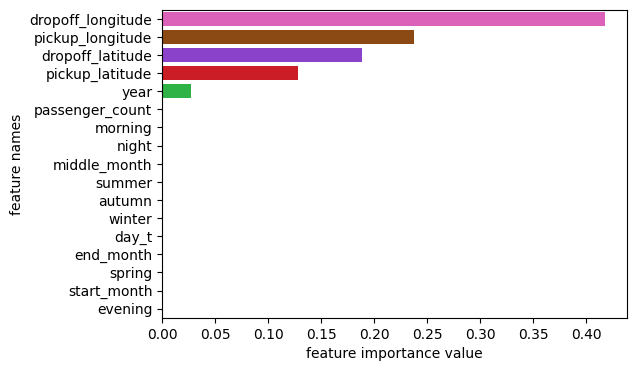

In [55]:
model_encoded = gs4.best_estimator_

sorted_ind = model_encoded.feature_importances_.argsort()[::-1]
sorted_feature_names = X_train.columns[sorted_ind]
sorted_importances = model_encoded.feature_importances_[sorted_ind]
data = pd.DataFrame(sorted_importances, index=sorted_feature_names, columns=['importance'])

fig = plt.figure(figsize=(6, 4))
plt.xlabel("feature importance value")
plt.ylabel("feature names")

sns.barplot(x=data.importance, y=data.index, data=data, hue=data.importance, legend=False, palette='bright')
plt.show()

The diagram shows that the passenger's pick-up and drop-off coordinates are still the most influential features. Among the time-related attributes, only the year stands out as important

## 5. Clusterization and Visualization

We'll remove outlier trips (distant rides) and keep only rows in df (after dropping missing values) that meet both conditions:

* `dropoff_latitude` $\in (39;41)$
* `dropoff_longitude` $\in (-75;-72)$

In [56]:
df_new = df[(df.dropoff_latitude<41) & (df.dropoff_latitude>39) & (df.dropoff_longitude>(-75)) & (df.dropoff_longitude<(-72))]

Let's break down all trips into 5 clusters based on `dropoff_latitude` and `dropoff_longitude` using k-means.

Then, visualize the trips from the df table on a scatter plot with `dropoff_latitude` on one axis and `dropoff_longitude` on the other, coloring the points by cluster.

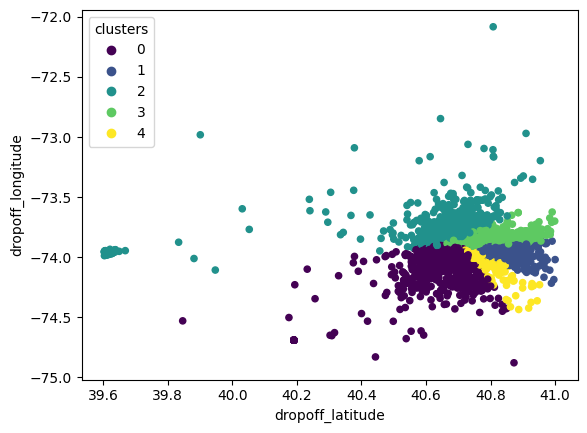

In [57]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(df_new[['dropoff_latitude', 'dropoff_longitude']])
# print(kmeans.labels_) 

sc = plt.scatter(df_new.dropoff_latitude, df_new.dropoff_longitude, c = kmeans.labels_, s=20, cmap='viridis')
plt.xlabel('dropoff_latitude')
plt.ylabel('dropoff_longitude')
plt.legend(*sc.legend_elements(), title='clusters');

For each cluster, let's calculate the average trip fare

In [58]:
for k in range(0, 5):
    ind = np.nonzero(kmeans.labels_ == k)
    d = df_new.iloc[ind]
    print(f'Average trip fare for cluster {k} is {round(d.fare_amount.mean(), 1)}')

Average trip fare for cluster 0 is 12.5
Average trip fare for cluster 1 is 10.3
Average trip fare for cluster 2 is 40.1
Average trip fare for cluster 3 is 23.9
Average trip fare for cluster 4 is 9.6


Now, let's isolate and visualize the cluster that has the highest average trip cost

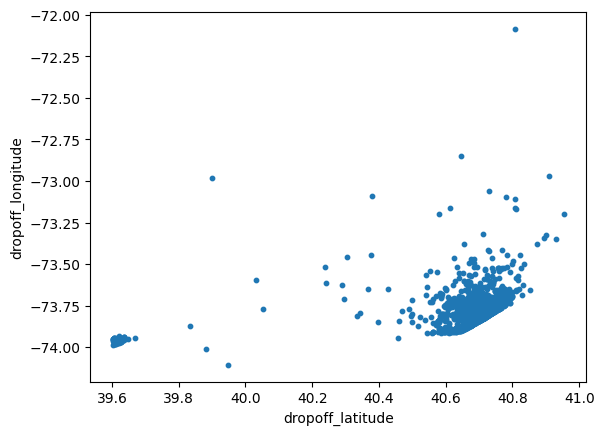

In [59]:
ind = np.nonzero(kmeans.labels_ == 2)
d_max = df_new.iloc[ind]

sc = plt.scatter(d_max.dropoff_latitude, d_max.dropoff_longitude, s=10)
plt.xlabel('dropoff_latitude')
plt.ylabel('dropoff_longitude');

Now, let's cluster the points from this cluster using DBSCAN with hyperparameters `eps=0.15` and `min_samples=10`.

Then, compute the centroid coordinates (arithmetic mean) of the smaller cluster (the little "island").

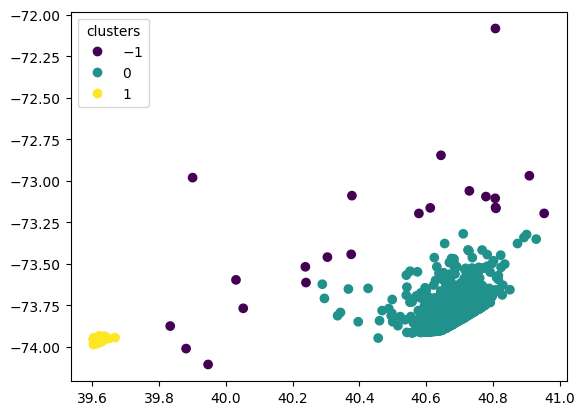

In [60]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.15, min_samples=10)
clusters = dbscan.fit_predict(d_max[['dropoff_latitude', 'dropoff_longitude']])

sc = plt.scatter(d_max.dropoff_latitude, d_max.dropoff_longitude, c = clusters)
plt.legend(*sc.legend_elements(), title='clusters');

In [61]:
ind = np.nonzero(clusters == 1)
d_1 = d_max[['dropoff_latitude', 'dropoff_longitude']].iloc[ind]
d_1.mean(axis = 0)

dropoff_latitude     39.616325
dropoff_longitude   -73.960964
dtype: float64

## Conclusions

The object of investigation of this project is a dataset containing taxi trip information, including dates, pickup and dropoff coordinates, and trip fares. Data preprocessing was performed, including handling missing values and extracting individual features from composite feature sets.

Exploratory data analysis revealed that the highest number of taxi orders occurs in the spring, with peak demand in the late afternoon and evening hours (after work and into the evening). Outliers were also detected in the data (remote pickup/dropoff locations).

A baseline decision tree model was built, achieving an R² of 0.5 on the test set. Feature importance was visualized based on this model, showing that pickup and dropoff longitudes have the greatest weight in predicting trip fare.

Several approaches were applied to improve the baseline model's performance:
* Log transformation of the target variable
* Introducing polynomial features
* Feature standardization and selection
* Encoding categorical features

All of these approaches helped to improve the baseline model. The most effective was introducing polynomial features, which boosted $R^2$ to 0.71.

On the dataset cleaned of outliers (excluding remote dropoff locations), clustering was performed on passenger dropoff points. The cluster with the highest average trip fare was identified. This cluster was then further clustered into 3 subclusters, and their geographic centroids were found. This illustrates the potential application of clustering — for example, in identifying potentially profitable customers based on the destination area of their trips.